# Analyzing the Relationship Between Job satisfaction in Employees and Different Factors 


## Abstract

**complete when finished

## Authors

Team Members: Roxana Behjat, Taishi Aizawa, Rajveer Barring, Brandon Su

## Background and Prior Work

Our group is investigating the factors that drive job satisfaction, as employee satisfaction is a key indicator of organizational health, strength, and productivity. The goal is to gain a more targeted, in-depth understanding of the workplace drivers of satisfaction by investigating how job satisfaction varies across departments and its relationship to performance ratings, promotion history, and other contributing factors. Findings from this type of analysis can help inform business strategies and assist organizations in identifying departments with lower satisfaction to target. This makes our research and findings valuable, as they can be used to help companies in these kinds of movements; our original motivation was to find a way to boost organizational health, and we found this to be a good way to look into it. 



## Hypothesis


We hypothesize job satisfaction is not evenly distributed across departments and that factors related to career growth, such as promotion history, will be positively associated with satisfaction. We expect that the specific parameters we have chosen, such as benefits and employee retention, will be positively correlated with employee satisfaction. While we acknowledge that not all employee data will necessarily have a significant impact on overall employee satisfaction, we hypothesize that certain factors strongly influence how employees view their company. 


## Data

### Data overview

- **Dataset: Global Satisfaction Index Results by Agency (US Office of Personnel Management)**
  - **Dataset Name:** Employee Performance and Productivity Data by mexwell
  - **Link to the dataset:** https://www.kaggle.com/datasets/mexwell/employee-performance-and-productivity-data/data
  - **Number of observations:** 100,000 employees
  - **Number of variables:** 20 columns (1 datetime, 1 bool, 2 float, 4 categorical/string, 12 int)
  - **Description of the variables:**

 - `Employee_ID` (string): Unique identifier for each employee. Treated as an identifier, not a numeric variable for calculation.
- `Department` (string): Department in which the employee works, such as Sales, HR, or IT.
- `Gender` (string): Gender of the employee, such as Male, Female, or Other.
- `Age` (integer): Employee's age, ranging from 22 to 60.
- `Job_Title` (string): Role held by the employee, such as Manager, Analyst, or Developer.
- `Hire_Date` (datetime): Date the employee was hired.
- `Years_At_Company` (integer): Number of years the employee has worked at the company.
- `Education_Level` (string): Highest educational qualification, such as High School, Bachelor, Master, or PhD.
- `Performance_Score` (integer, 1–5): Employee's performance rating on a 1 to 5 scale.
- `Monthly_Salary` (float, USD): Employee's monthly salary in U.S. dollars.
- `Work_Hours_Per_Week` (integer): Number of hours the employee works per week.
- `Projects_Handled` (integer): Total number of projects handled by the employee.
- `Overtime_Hours` (integer): Total overtime hours worked by the employee in the last year.
- `Sick_Days` (integer): Number of sick days taken by the employee.
- `Remote_Work_Frequency` (integer, 0–100): Percentage of time the employee works remotely.
- `Team_Size` (integer): Number of people in the employee's team.
- `Training_Hours` (integer): Number of hours the employee spent in training.
- `Promotions` (integer): Number of promotions the employee has received during their tenure.
- `Employee_Satisfaction_Score` (float, 1.0–5.0): Employee satisfaction rating on a 1.0 to 5.0 scale.
- `Resigned` (boolean): Whether the employee has resigned from the company.



- **Shortcomings of this dataset:**
  - The data is hypothetical, not from a research study but instead artificially genrated.


In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from kagglehub import KaggleDatasetAdapter

df_raw = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "mexwell/employee-performance-and-productivity-data",
    "Extended_Employee_Performance_and_Productivity_Data.csv",
)

df_raw.head()


/opt/anaconda3/envs/Math189/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


The first thing we did was move the employee ID to be the index, and then take a look at the shape of the data:

In [2]:
df_raw.set_index('Employee_ID', inplace=True)
print(f"Full dataset shape: {df_raw.shape}")
print()

print(f"  Rows (observations): {df_raw.shape[0]}")
print(f"  Columns (variables): {df_raw.shape[1]}")
print()
print(f"  Departments: {df_raw['Department'].unique()}")
print(f"  Job Titles: {df_raw['Job_Title'].unique()}")

df_raw.head()


Full dataset shape: (100000, 19)

  Rows (observations): 100000
  Columns (variables): 19

  Departments: <StringArray>
[              'IT',          'Finance', 'Customer Support',
      'Engineering',        'Marketing',               'HR',
       'Operations',            'Sales',            'Legal']
Length: 9, dtype: str
  Job Titles: <StringArray>
['Specialist',  'Developer',    'Analyst',    'Manager', 'Technician',
   'Engineer', 'Consultant']
Length: 7, dtype: str


,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
Employee_ID,,,,,,,,,,,,,,,,,,,
1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


We then looked at what each column's dtype was:

In [3]:
print("Column names and dtypes:")
print(df_raw.dtypes)
print()

Column names and dtypes:
Department                         str
Gender                             str
Age                              int64
Job_Title                          str
Hire_Date                          str
Years_At_Company                 int64
Education_Level                    str
Performance_Score                int64
Monthly_Salary                 float64
Work_Hours_Per_Week              int64
Projects_Handled                 int64
Overtime_Hours                   int64
Sick_Days                        int64
Remote_Work_Frequency            int64
Team_Size                        int64
Training_Hours                   int64
Promotions                       int64
Employee_Satisfaction_Score    float64
Resigned                          bool
dtype: object



We then adjusted accordingly, making each column the appropriate string, datetime, etc.

In [4]:
df_raw["Job_Title"] = df_raw["Job_Title"].astype("string")
df_raw["Department"] = df_raw["Department"].astype("string")
df_raw["Education_Level"] = df_raw["Education_Level"].astype("string")
df_raw["Gender"] = df_raw["Gender"].astype("string")
df_raw["Gender"] = df_raw["Gender"].astype("string")
df_raw['Hire_Date'] = pd.to_datetime(df_raw['Hire_Date'])

In [5]:
print("Column names and dtypes:")
print(df_raw.dtypes)
print()

Column names and dtypes:
Department                             string
Gender                                 string
Age                                     int64
Job_Title                              string
Hire_Date                      datetime64[us]
Years_At_Company                        int64
Education_Level                        string
Performance_Score                       int64
Monthly_Salary                        float64
Work_Hours_Per_Week                     int64
Projects_Handled                        int64
Overtime_Hours                          int64
Sick_Days                               int64
Remote_Work_Frequency                   int64
Team_Size                               int64
Training_Hours                          int64
Promotions                              int64
Employee_Satisfaction_Score           float64
Resigned                                 bool
dtype: object



We then took a look at the number of missing values in the dataset, and there are none.

Missing values per column:
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

No missing values found in any column.


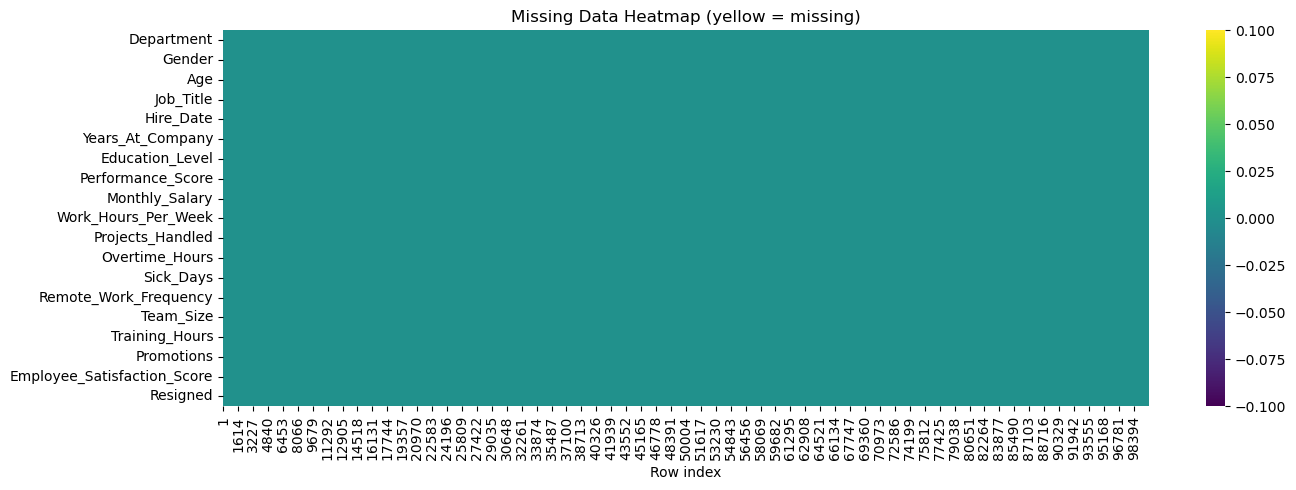


Rows with at least one missing value: 0 / 100000 (0.00%)


In [6]:
missing_counts = df_raw.isnull().sum()
missing_pct = (df_raw.isnull().sum() / len(df_raw)) * 100
missing_summary = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_pct': missing_pct
}).sort_values('missing_count', ascending=False)

print("Missing values per column:")
print(missing_summary[missing_summary['missing_count'] > 0])
print()
if missing_summary['missing_count'].sum() == 0:
    print("No missing values found in any column.")
else:
    print(f"Total missing values: {missing_summary['missing_count'].sum()}")

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(df_raw.isnull().T, cbar=True, yticklabels=True, cmap='viridis', ax=ax)
ax.set_title('Missing Data Heatmap (yellow = missing)')
ax.set_xlabel('Row index')
plt.tight_layout()
plt.show()

rows_with_missing = df_raw.isnull().any(axis=1).sum()
print(f"\nRows with at least one missing value: {rows_with_missing} / {len(df_raw)} "
      f"({rows_with_missing / len(df_raw):.2%})")

## Results

### Exploratory Data Analysis


Before running formal statistical tests, we first explore the structure of the employee data to understand what patterns are visible in the sample. This EDA section reviews the distribution of employee satisfaction, compares satisfaction across departments, and examines whether satisfaction appears to vary with performance scores, promotion history, salary, tenure, and retention status. We also check missing values, possible outliers, and variables that may be less useful for the main research question. The goal is to identify the strongest visible patterns and limitations in the data before moving into formal analysis.

In [7]:
df_eda = df_raw.copy()

if 'Employee_ID' in df_eda.columns:
    df_eda = df_eda.set_index('Employee_ID')

satisfaction_col = 'Employee_Satisfaction_Score'
main_numeric_cols = [
    satisfaction_col,
    'Performance_Score',
    'Promotions',
    'Monthly_Salary',
    'Years_At_Company',
    'Work_Hours_Per_Week',
    'Overtime_Hours',
    'Training_Hours',
    'Projects_Handled',
    'Sick_Days',
    'Team_Size',
    'Age',
    'Remote_Work_Frequency'
]
main_numeric_cols = [col for col in main_numeric_cols if col in df_eda.columns]

summary_stats = df_eda[main_numeric_cols].describe().T
summary_stats = summary_stats[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(2)
summary_stats

,count,mean,std,min,25%,50%,75%,max
Employee_Satisfaction_Score,100000.0,3.00,1.15,1.0,2.01,3.0,3.99,5.0
Performance_Score,100000.0,3.00,1.41,1.0,2.00,3.0,4.00,5.0
Promotions,100000.0,1.00,0.82,0.0,0.00,1.0,2.00,2.0
Monthly_Salary,100000.0,6403.21,1372.51,3850.0,5250.00,6500.0,7500.00,9000.0
Years_At_Company,100000.0,4.48,2.87,0.0,2.00,4.0,7.00,10.0
Work_Hours_Per_Week,100000.0,44.96,8.94,30.0,37.00,45.0,53.00,60.0
Overtime_Hours,100000.0,14.51,8.66,0.0,7.00,15.0,22.00,29.0
Training_Hours,100000.0,49.51,28.89,0.0,25.00,49.0,75.00,99.0
Projects_Handled,100000.0,24.43,14.47,0.0,12.00,24.0,37.00,49.0
Sick_Days,100000.0,7.01,4.33,0.0,3.00,7.0,11.00,14.0


The summary statistics show that job satisfaction is centered almost exactly at 3 on a 1 to 5 scale, with the middle half of employees between about 2.01 and 3.99. Performance scores, promotion counts, remote-work frequency, and departments are also very evenly represented, so the dataset is large but fairly balanced. Salary ranges from 3850 to 9000 per month, while tenure ranges from 0 to 10 years.

In [8]:
# Missingness table
missing_summary = pd.DataFrame({
    'missing_count': df_eda.isna().sum(),
    'missing_pct': (df_eda.isna().mean() * 100).round(2)
}).sort_values(['missing_count', 'missing_pct'], ascending=False)
missing_summary

,missing_count,missing_pct
Department,0,0.0
Gender,0,0.0
Age,0,0.0
Job_Title,0,0.0
Hire_Date,0,0.0
Years_At_Company,0,0.0
Education_Level,0,0.0
Performance_Score,0,0.0
Monthly_Salary,0,0.0
Work_Hours_Per_Week,0,0.0


In [9]:
# Basic check for outliers
outlier_rows = []
for col in main_numeric_cols:
    q1 = df_eda[col].quantile(0.25)
    q3 = df_eda[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = ((df_eda[col] < lower) | (df_eda[col] > upper)).sum()
    outlier_rows.append({
        'variable': col,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'lower_bound': lower,
        'upper_bound': upper,
        'outlier_count': outlier_count,
        'outlier_pct': 100 * outlier_count / len(df_eda)
    })

outlier_summary = pd.DataFrame(outlier_rows).round(2)
outlier_summary

,variable,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_pct
0,Employee_Satisfaction_Score,2.01,3.99,1.98,-0.96,6.96,0,0.0
1,Performance_Score,2.00,4.00,2.00,-1.00,7.00,0,0.0
2,Promotions,0.00,2.00,2.00,-3.00,5.00,0,0.0
3,Monthly_Salary,5250.00,7500.00,2250.00,1875.00,10875.00,0,0.0
4,Years_At_Company,2.00,7.00,5.00,-5.50,14.50,0,0.0
5,Work_Hours_Per_Week,37.00,53.00,16.00,13.00,77.00,0,0.0
6,Overtime_Hours,7.00,22.00,15.00,-15.50,44.50,0,0.0
7,Training_Hours,25.00,75.00,50.00,-50.00,150.00,0,0.0
8,Projects_Handled,12.00,37.00,25.00,-25.50,74.50,0,0.0
9,Sick_Days,3.00,11.00,8.00,-9.00,23.00,0,0.0


There are no missing values in the variables used here. The check does not flag outliers in the main numeric variables. This makes sense because many variables appear to have fixed, bounded ranges in the dataset,

satisfaction is between 1 and 5
performance is between 1 and 5
promotions are 0 to 2
and tenure is 0 to 10 years

Nuisance variables for our main question include `Employee_ID`, which is only an identifier, and `Hire_Date`, which mainly the same information as `Years_At_Company`. Demographic variables such as `Gender`, `Age`, `Education_Level`, and `Job_Title` are not the main focus of this EDA section, but they could possible matter later as background variables when interpreting department, salary, or promotion patterns. We acknowledge that these and other variables outside of this dataset could also be important for understanding employee satisfaction, but we focus on our covariates defined in the hypothesis for our analysis.

In [10]:
# Grouped summary tables for the main relationships of interest.
dept_summary = (
    df_eda.groupby('Department')
    .agg(
        n=(satisfaction_col, 'size'),
        mean_satisfaction=(satisfaction_col, 'mean'),
        median_satisfaction=(satisfaction_col, 'median'),
        sd_satisfaction=(satisfaction_col, 'std'),
        resigned_rate=('Resigned', 'mean'),
        mean_salary=('Monthly_Salary', 'mean'),
        median_tenure=('Years_At_Company', 'median')
    )
    .sort_values('mean_satisfaction', ascending=False)
)
dept_summary['resigned_rate'] = dept_summary['resigned_rate'] * 100
dept_summary.round(2)

,n,mean_satisfaction,median_satisfaction,sd_satisfaction,resigned_rate,mean_salary,median_tenure
Department,,,,,,,
Operations,11181,3.03,3.03,1.15,10.03,6412.31,4.0
IT,11131,3.02,3.03,1.15,9.56,6414.60,4.0
Finance,11200,3.00,2.99,1.15,10.54,6398.58,4.0
Engineering,10956,3.00,2.99,1.14,9.65,6417.25,4.0
HR,10960,3.00,3.02,1.14,10.26,6400.36,4.0
Marketing,11216,2.99,2.98,1.15,10.03,6377.86,5.0
Sales,11122,2.99,2.99,1.16,9.93,6413.15,4.0
Legal,11118,2.99,2.98,1.15,10.22,6391.28,4.0
Customer Support,11116,2.97,2.96,1.15,9.88,6403.88,4.0


In [11]:
performance_summary = (
    df_eda.groupby('Performance_Score')
    .agg(
        n=(satisfaction_col, 'size'),
        mean_satisfaction=(satisfaction_col, 'mean'),
        median_satisfaction=(satisfaction_col, 'median'),
        resigned_rate=('Resigned', 'mean')
    )
    .sort_index()
)
performance_summary['resigned_rate'] = performance_summary['resigned_rate'] * 100

promotion_summary = (
    df_eda.groupby('Promotions')
    .agg(
        n=(satisfaction_col, 'size'),
        mean_satisfaction=(satisfaction_col, 'mean'),
        median_satisfaction=(satisfaction_col, 'median'),
        resigned_rate=('Resigned', 'mean'),
        median_salary=('Monthly_Salary', 'median'),
        median_tenure=('Years_At_Company', 'median')
    )
    .sort_index()
)
promotion_summary['resigned_rate'] = promotion_summary['resigned_rate'] * 100

retention_summary = (
    df_eda.groupby('Resigned')
    .agg(
        n=(satisfaction_col, 'size'),
        mean_satisfaction=(satisfaction_col, 'mean'),
        median_satisfaction=(satisfaction_col, 'median'),
        mean_salary=('Monthly_Salary', 'mean'),
        median_tenure=('Years_At_Company', 'median'),
        mean_overtime=('Overtime_Hours', 'mean')
    )
    .sort_index()
)

print('Satisfaction by performance score')
display(performance_summary.round(2))
print('Satisfaction by promotion count')
display(promotion_summary.round(2))
print('Retention summary')
display(retention_summary.round(2))

Satisfaction by performance score


,n,mean_satisfaction,median_satisfaction,resigned_rate
Performance_Score,,,,
1,20120,2.99,2.99,10.11
2,20013,3.00,3.02,9.95
3,19999,3.00,3.00,10.10
4,19940,3.00,2.99,10.19
5,19928,3.00,2.99,9.70


Satisfaction by promotion count


,n,mean_satisfaction,median_satisfaction,resigned_rate,median_salary,median_tenure
Promotions,,,,,,
0,33296,2.99,2.99,10.04,6500.0,4.0
1,33436,3.01,3.02,10.00,6500.0,4.0
2,33268,2.99,2.98,9.99,6500.0,4.0


Retention summary


,n,mean_satisfaction,median_satisfaction,mean_salary,median_tenure,mean_overtime
Resigned,,,,,,
False,89990,3.00,3.00,6403.91,4.0,14.51
True,10010,2.99,2.99,6396.94,4.0,14.58


The department table shows only a small difference in average satisfaction between departments. Operations and IT are the highest in this sample, while Customer Support is the lowest, but all department means are still very close to 3. The performance, promotion, and retention tables show even weaker separation, where the mean and median satsfaction scores are almost identical across all groups. This suggests that any later formal tests may find small effects because the sample is very large, but the practical differences seen in EDA are not large.

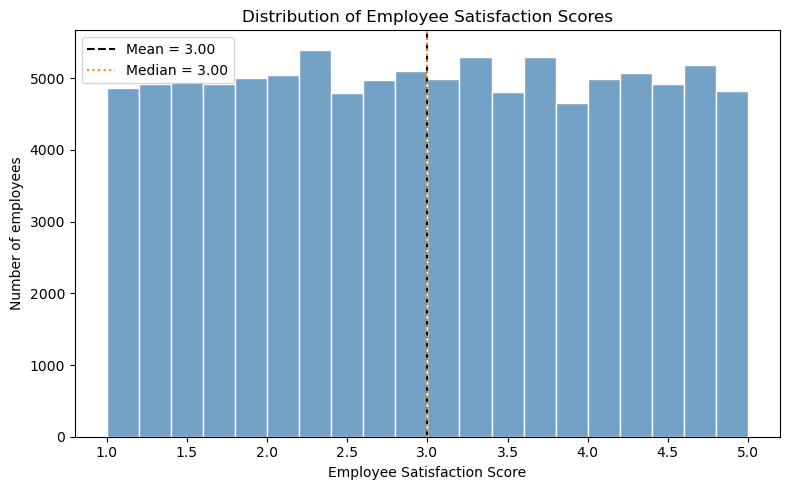

In [12]:
# Overall job satisfaction distribution.
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df_eda[satisfaction_col], bins=20, color='steelblue', edgecolor='white', ax=ax)
ax.axvline(df_eda[satisfaction_col].mean(), color='black', linestyle='--', label=f"Mean = {df_eda[satisfaction_col].mean():.2f}")
ax.axvline(df_eda[satisfaction_col].median(), color='darkorange', linestyle=':', label=f"Median = {df_eda[satisfaction_col].median():.2f}")
ax.set_title('Distribution of Employee Satisfaction Scores')
ax.set_xlabel('Employee Satisfaction Score')
ax.set_ylabel('Number of employees')
ax.legend()
plt.tight_layout()
plt.show()

This histogram is the best starting visual because it shows the outcome variable directly. Satisfaction is spread relatively evenly across the full 1 to 5 scale and is centered near 3, with identical mean and median values of 3. There is no obvious skew or pile-up at only high or low scores, so the distribution is fairly balanced. This suggests there might not be a strong driver in job satisfaction, but we investigate further along in our analysis.

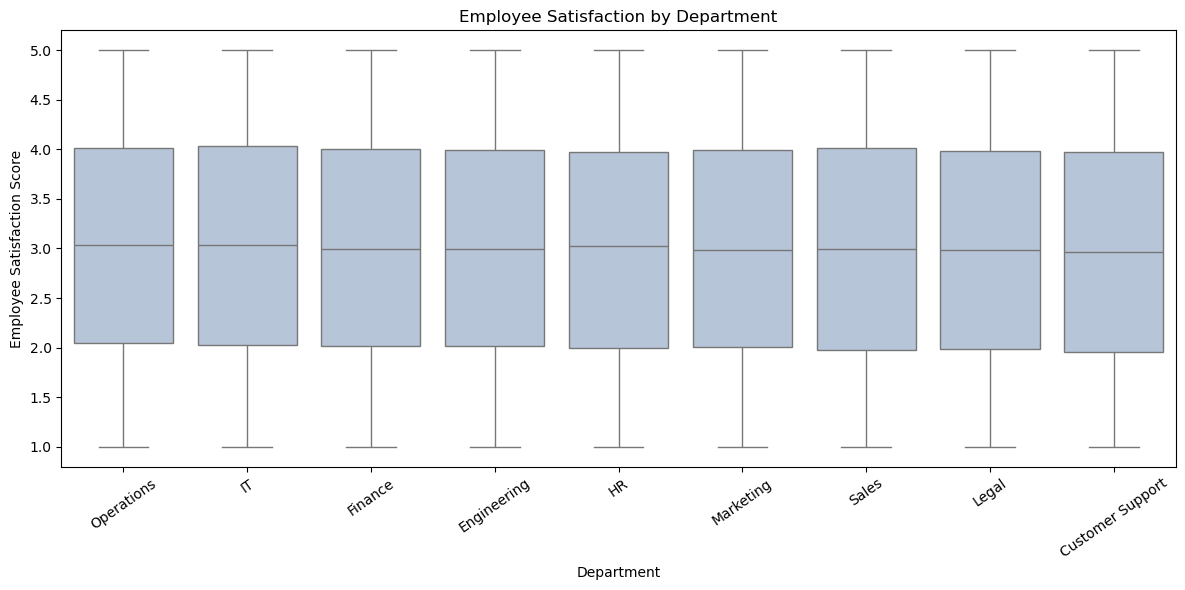

In [13]:
# Satisfaction by department.
dept_order = dept_summary.index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=df_eda,
    x='Department',
    y=satisfaction_col,
    order=dept_order,
    color='lightsteelblue',
    ax=ax
)
ax.set_title('Employee Satisfaction by Department')
ax.set_xlabel('Department')
ax.set_ylabel('Employee Satisfaction Score')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

This boxplot plots the satisfaction scores across different departments. Visually, the plot for each department are extremely similar, almost identical. Although technically Operations and IT have the highest mean satisfaction in the table, and Customer Support has the lowest, their plots are visually similar. The visual pattern is modest, so department may matter, but EDA does not show a large department gap by itself.

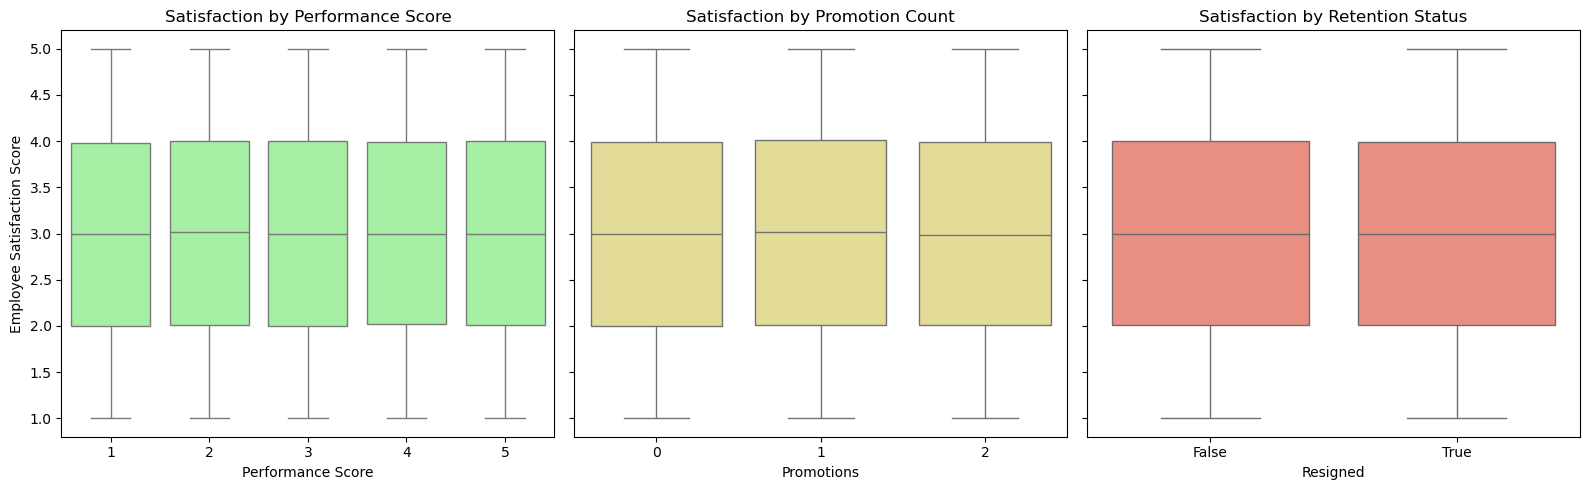

In [14]:
# Satisfaction across performance, promotions, and retention
fig, axs = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

sns.boxplot(data=df_eda, x='Performance_Score', y=satisfaction_col, color='palegreen', ax=axs[0])
axs[0].set_title('Satisfaction by Performance Score')
axs[0].set_xlabel('Performance Score')
axs[0].set_ylabel('Employee Satisfaction Score')

sns.boxplot(data=df_eda, x='Promotions', y=satisfaction_col, color='khaki', ax=axs[1])
axs[1].set_title('Satisfaction by Promotion Count')
axs[1].set_xlabel('Promotions')
axs[1].set_ylabel('')

sns.boxplot(data=df_eda, x='Resigned', y=satisfaction_col, color='salmon', ax=axs[2])
axs[2].set_title('Satisfaction by Retention Status')
axs[2].set_xlabel('Resigned')
axs[2].set_ylabel('')

plt.tight_layout()
plt.show()

Before formal testing, performance score, promotion history, and resignation status do not show a clear visible separation in satisfaction. Promotion count also does not show the positive pattern we expected in the hypothesis. Employees with 0, 1, or 2 promotions have nearly the same satisfaction distribution. Similarly, performance scores between 1 through 5 have visibly similar satisfaction distrubutions, alongside resignation status. This suggests that later formal tests may find small effects because of sample size, but the difference is not large enough to be obvious in EDA.

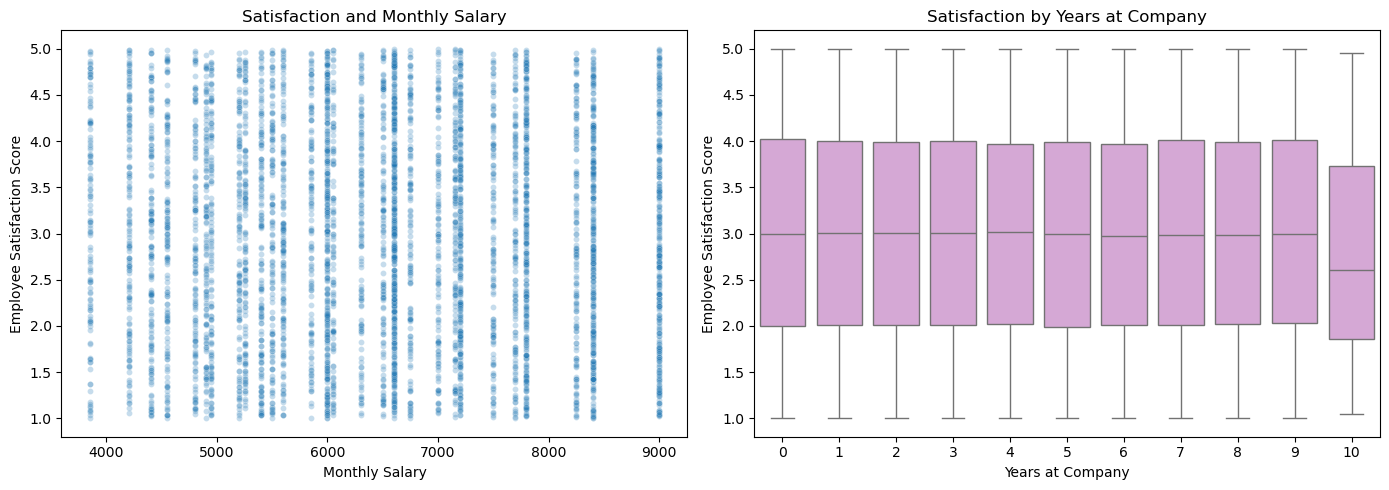

In [15]:
# Salary and tenure visuals
plot_sample = df_eda.sample(n=5000, random_state=189) if len(df_eda) > 5000 else df_eda

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=plot_sample,
    x='Monthly_Salary',
    y=satisfaction_col,
    alpha=0.25,
    s=18,
    ax=axs[0]
)
axs[0].set_title('Satisfaction and Monthly Salary')
axs[0].set_xlabel('Monthly Salary')
axs[0].set_ylabel('Employee Satisfaction Score')

sns.boxplot(
    data=df_eda,
    x='Years_At_Company',
    y=satisfaction_col,
    color='plum',
    ax=axs[1]
)
axs[1].set_title('Satisfaction by Years at Company')
axs[1].set_xlabel('Years at Company')
axs[1].set_ylabel('Employee Satisfaction Score')

plt.tight_layout()
plt.show()

The scatterplot visualizes the relationship between monthly salary and employee satisfaction. It does not show a strong visual trend, as low, middle, and high salary employees all cover nearly the full satisfaction range. The tenure boxplot visualizes the distribution of satisfaction across different levels of tenure. The tenure pattern is similarly flat across 0 to 10 years at the company, with the sole exception of 10 years at the company having a distinctly lower satisfaction level. Based on EDA alone, salary does not appear to be strong standalone explanations for satisfaction in this dataset. Although tenure does show a visible dip in satisfaction at 10 years, the rest of the tenure levels are visually similar. Further testing is needed to determine whether the 10-year tenure group is a significant indicator of lower satisfaction.

## Statistical Analysis


This section tests the main research question formally. First, we use a one-way ANOVA to test whether average employee satisfaction differs by department. Then, we fit a multiple linear regression model predicting employee satisfaction from performance, promotions, department, tenure, salary, and other work-related covariates. Finally, we check regression assumptions using residual diagnostics, equal-variance tests, and VIF scores for multicollinearity.

In [16]:
# Statistical Analysis Part 1: ANOVA
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy import stats

# Use the cleaned EDA dataframe if it exists; otherwise fall back to df_raw.
try:
    analysis_df = df_eda.copy()
except NameError:
    analysis_df = df_raw.copy()

satisfaction_col = "Employee_Satisfaction_Score"

# One-way ANOVA: does mean satisfaction differ by department?
anova_model = smf.ols(f"{satisfaction_col} ~ C(Department)", data=analysis_df).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)

# Effect size: eta-squared = SS_between / SS_total
ss_department = anova_table.loc["C(Department)", "sum_sq"]
ss_residual = anova_table.loc["Residual", "sum_sq"]
eta_squared = ss_department / (ss_department + ss_residual)

dept_satisfaction_summary = (
    analysis_df.groupby("Department")[satisfaction_col]
    .agg(n="count", mean="mean", median="median", sd="std")
    .sort_values("mean", ascending=False)
)

print("Department satisfaction summary:")
display(dept_satisfaction_summary.round(4))

print("\nANOVA table:")
display(anova_table.round(6))

print(f"\nEta-squared effect size: {eta_squared:.6f}")

Department satisfaction summary:


,n,mean,median,sd
Department,,,,
Operations,11181,3.0259,3.03,1.1463
IT,11131,3.0232,3.03,1.1517
Finance,11200,3.0040,2.99,1.1497
Engineering,10956,3.0029,2.99,1.1445
HR,10960,2.9951,3.02,1.1450
Marketing,11216,2.9941,2.98,1.1510
Sales,11122,2.9933,2.99,1.1609
Legal,11118,2.9850,2.98,1.1529
Customer Support,11116,2.9680,2.96,1.1536



ANOVA table:


,sum_sq,df,F,PR(>F)
C(Department),28.710568,8.0,2.710643,0.005537
Residual,132385.481931,99991.0,NaN,NaN



Eta-squared effect size: 0.000217


**ANOVA interpretation.** The one-way ANOVA suggests that there is evidence that at least one department has a different mean satisfaction score, F(8,99991)=2.71, p=0.0055. However, the effect size is extremely small, $η^2
≈0.00022.$ This means department explains only about 0.02% of the variation in satisfaction. In practical terms, the department differences are statistically detectable because the sample size is very large, but the actual differences are tiny. The highest mean departments are Operations and IT, while Customer Support has the lowest mean, but all department averages are close to 3 on the 1–5 satisfaction scale.

In [17]:
# Optional post-hoc comparison after ANOVA: Tukey HSD
# This checks which department pairs differ after adjusting for multiple comparisons.
tukey = pairwise_tukeyhsd(
    endog=analysis_df[satisfaction_col],
    groups=analysis_df["Department"],
    alpha=0.05
)

tukey_df = pd.DataFrame(
    data=tukey._results_table.data[1:],
    columns=tukey._results_table.data[0]
)

significant_pairs = tukey_df[tukey_df["reject"] == True].sort_values("p-adj")

print("Significant Tukey HSD department pairs:")
display(significant_pairs)

if significant_pairs.empty:
    print("No department pairs were significantly different after Tukey correction.")

Significant Tukey HSD department pairs:


,group1,group2,meandiff,p-adj,lower,upper,reject
6,Customer Support,Operations,0.0579,0.0054,0.0101,0.1057,True
3,Customer Support,IT,0.0552,0.0105,0.0073,0.1031,True


Tukey HSD found two significant department-level differences in satisfaction after adjusting for multiple comparisons. Customer Support had significantly lower average satisfaction than Operations, with a mean difference of 0.0579 and adjusted p-value of 0.0054. Customer Support also had significantly lower average satisfaction than IT, with a mean difference of 0.0552 and adjusted p-value of 0.0105. No other department pairs showed significant differences. However, the size of these differences is relatively small, so the practical importance may be limited

In [18]:
# Statistical Analysis Part 2: Multiple Linear Regression
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices

# Main regression model.
# We exclude Employee_ID because it is only an identifier and Hire_Date because Years_At_Company captures tenure more directly.
regression_formula = '''
Employee_Satisfaction_Score ~ Performance_Score + Promotions + C(Department)
+ Years_At_Company + Monthly_Salary + Work_Hours_Per_Week + Overtime_Hours
+ Training_Hours + Projects_Handled + Sick_Days + Team_Size + Age
+ Remote_Work_Frequency + Resigned
'''

ols_model = smf.ols(regression_formula, data=analysis_df).fit()

print(ols_model.summary())

                                 OLS Regression Results                                
Dep. Variable:     Employee_Satisfaction_Score   R-squared:                       0.000
Model:                                     OLS   Adj. R-squared:                  0.000
Method:                          Least Squares   F-statistic:                     1.341
Date:                         Sat, 06 Jun 2026   Prob (F-statistic):              0.136
Time:                                 12:15:01   Log-Likelihood:            -1.5592e+05
No. Observations:                       100000   AIC:                         3.119e+05
Df Residuals:                            99978   BIC:                         3.121e+05
Df Model:                                   21                                         
Covariance Type:                     nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
-----------------------

In [19]:
# Cleaner coefficient table for the regression model
coef_table = pd.DataFrame({
    "term": ols_model.params.index,
    "coef": ols_model.params.values,
    "std_err": ols_model.bse.values,
    "t": ols_model.tvalues.values,
    "p_value": ols_model.pvalues.values
})

display(coef_table.round(6))

print(f"R-squared: {ols_model.rsquared:.6f}")
print(f"Adjusted R-squared: {ols_model.rsquared_adj:.6f}")
print(f"Overall model F-test p-value: {ols_model.f_pvalue:.6f}")

,term,coef,std_err,t,p_value
0,Intercept,2.957756,0.034513,85.699206,0.000000
1,C(Department)[T.Engineering],0.034800,0.015492,2.246369,0.024683
2,C(Department)[T.Finance],0.036011,0.015406,2.337449,0.019418
3,C(Department)[T.HR],0.027137,0.015490,1.751881,0.079797
4,C(Department)[T.IT],0.054948,0.015430,3.561021,0.000370
5,C(Department)[T.Legal],0.017065,0.015435,1.105617,0.268895
6,C(Department)[T.Marketing],0.025918,0.015401,1.682886,0.092400
7,C(Department)[T.Operations],0.057855,0.015413,3.753685,0.000174
8,C(Department)[T.Sales],0.025076,0.015433,1.624829,0.104202
9,Resigned[T.True],-0.010632,0.012125,-0.876840,0.380575


R-squared: 0.000282
Adjusted R-squared: 0.000072
Overall model F-test p-value: 0.135501


**Multiple Linear Regression Interpretation**: The multiple linear regression model did not meaningfully explain employee satisfaction, with \(R^2 = 0.000282\) and adjusted \(R^2 = 0.000072\). This means the predictors explain almost none of the variation in satisfaction scores.

The overall model F-test was not statistically significant, \(p = 0.1355\), suggesting that the predictors as a group do not significantly improve prediction of employee satisfaction.

Some department indicators, such as IT and Operations, were statistically significant relative to Customer Support, but their coefficients were very small, around 0.05 points on the 1–5 satisfaction scale.

Most other variables, including performance score, promotions, salary, work hours, age, resignation status, and remote work frequency, were not statistically significant.

Overall, the regression suggests that employee satisfaction is not strongly explained by the available workplace variables in this dataset.

In [20]:
# Statistical Analysis Part 3: Assumption Checks

# 1. Equal variance across departments using Levene's test.
department_groups = [
    group[satisfaction_col].values
    for _, group in analysis_df.groupby("Department")
]
levene_stat, levene_p = stats.levene(*department_groups, center="median")

print("Levene test for equal variance across departments:")
print(f"Statistic = {levene_stat:.4f}, p-value = {levene_p:.4f}")

# 2. Breusch-Pagan test for heteroskedasticity in the regression residuals.
bp_test = het_breuschpagan(ols_model.resid, ols_model.model.exog)
bp_labels = ["LM statistic", "LM p-value", "F statistic", "F p-value"]
bp_results = pd.Series(bp_test, index=bp_labels)

print("\nBreusch-Pagan test for regression equal variance:")
display(bp_results.round(6))

# 3. Multicollinearity check using VIF.
# We include the intercept in the design matrix when computing VIF,
# then remove it from the displayed table because the intercept VIF is not interpreted.
y_design, X_design = dmatrices(regression_formula, data=analysis_df, return_type="dataframe")

vif_table = pd.DataFrame({
    "variable": X_design.columns,
    "VIF": [
        variance_inflation_factor(X_design.values, i)
        for i in range(X_design.shape[1])
    ]
})

vif_table = (
    vif_table[vif_table["variable"] != "Intercept"]
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

print("\nVIF table:")
display(vif_table.round(3))

# 4. Residual distribution summary.
residual_summary = pd.Series(ols_model.resid).describe()
print("\nResidual summary:")
display(residual_summary.round(4))

# 5. Normality check.
# With n = 100,000, formal normality tests are extremely sensitive,
# so we interpret plots and residual shape more than just the p-value.
jb_stat, jb_p = stats.jarque_bera(ols_model.resid)
dw_stat = sm.stats.stattools.durbin_watson(ols_model.resid)

print(f"\nJarque-Bera normality test: statistic = {jb_stat:.4f}, p-value = {jb_p:.4g}")
print(f"Durbin-Watson statistic: {dw_stat:.4f}")

Levene test for equal variance across departments:
Statistic = 1.1415, p-value = 0.3313

Breusch-Pagan test for regression equal variance:


LM statistic    16.756923
LM p-value       0.725732
F statistic      0.797907
F p-value        0.725773
dtype: float64


VIF table:


,variable,VIF
0,C(Department)[T.Marketing],1.784
1,C(Department)[T.Finance],1.783
2,C(Department)[T.Operations],1.782
3,C(Department)[T.IT],1.779
4,C(Department)[T.Sales],1.778
5,C(Department)[T.Legal],1.778
6,C(Department)[T.HR],1.768
7,C(Department)[T.Engineering],1.768
8,Performance_Score,1.352
9,Monthly_Salary,1.352



Residual summary:


count    100000.0000
mean         -0.0000
std           1.1506
min          -2.0410
25%          -0.9900
50%          -0.0027
75%           0.9950
max           2.0609
dtype: float64


Jarque-Bera normality test: statistic = 5905.1823, p-value = 0
Durbin-Watson statistic: 1.9974


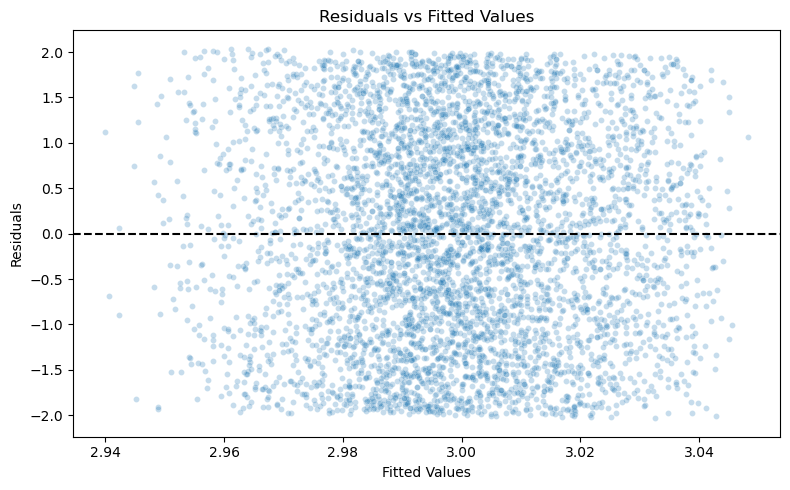

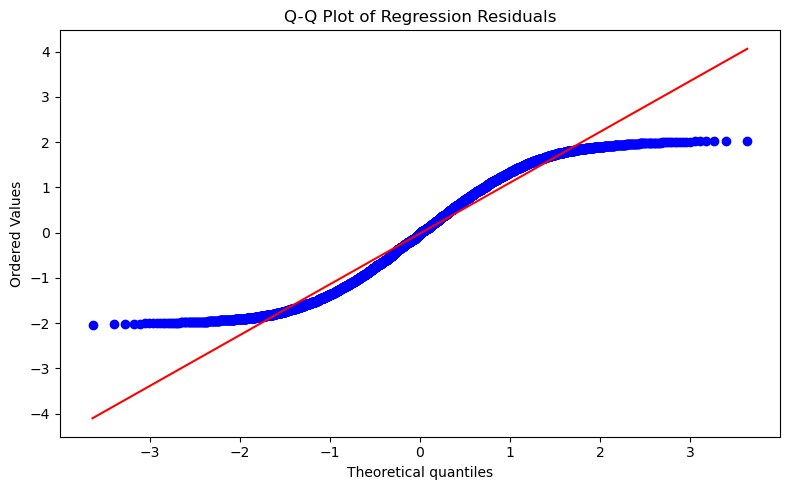

In [21]:
# Residual diagnostic plots
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as scipy_stats

# Use a sample for plots so the figures are readable.
plot_df = pd.DataFrame({
    "fitted": ols_model.fittedvalues,
    "residuals": ols_model.resid
}).sample(n=5000, random_state=189)

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=plot_df, x="fitted", y="residuals", alpha=0.25, s=18, ax=ax)
ax.axhline(0, linestyle="--", color="black")
ax.set_title("Residuals vs Fitted Values")
ax.set_xlabel("Fitted Values")
ax.set_ylabel("Residuals")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
scipy_stats.probplot(ols_model.resid.sample(n=5000, random_state=189), dist="norm", plot=ax)
ax.set_title("Q-Q Plot of Regression Residuals")
plt.tight_layout()
plt.show()

**Assumption checks interpretation.**

The assumption checks suggest that the model does not have major problems with equal variance, multicollinearity, or autocorrelation. However, the residuals are not perfectly normally distributed.

First, Levene’s test was used to check whether satisfaction scores had equal variance across departments. The test was not statistically significant, \(p = 0.3313\), so there is no strong evidence that the department variances are different. This supports the equal variance assumption for the ANOVA.

Second, the Breusch-Pagan test was used to check for heteroskedasticity in the regression residuals. This test was also not statistically significant, with \(p = 0.7257\). This suggests that the regression residuals do not show strong evidence of unequal variance.

The residuals vs fitted values plot also supports this. The points are spread fairly evenly around the horizontal line at 0, with no clear funnel shape or curved pattern. This suggests that the equal variance assumption is reasonable. However, the fitted values are all very close to 3, which matches the very low \(R^2\). This shows that the model is mostly predicting values near the overall average satisfaction score rather than explaining much individual variation.

The VIF values were all low. The largest VIF values were around 1.78 for the department dummy variables, and the rest were close to 1. Since these values are far below common concern thresholds such as 5 or 10, there does not appear to be a multicollinearity problem.

The residual summary shows that the residuals are centered near 0, which is expected for an OLS regression with an intercept. The residual standard deviation is about 1.15, with residuals ranging from about -2.04 to 2.06.

The Q-Q plot and Jarque-Bera test suggest that the residuals are not perfectly normal. The Q-Q plot shows an S-shaped pattern, with the tails flattening instead of following the straight reference line. This likely happens because satisfaction scores are bounded on a 1–5 scale, so the residuals are also limited in how extreme they can be. The Jarque-Bera test was significant, \(p < 0.001\), but because the sample size is very large (\(n = 100{,}000\)), formal normality tests are extremely sensitive to small deviations.

Finally, the Durbin-Watson statistic was 1.9974, which is very close to 2. This suggests there is no strong evidence of autocorrelation in the residuals.

Overall, the assumption checks do not show major issues with equal variance, multicollinearity, or autocorrelation. The main issue is that the residuals are not perfectly normal, but this is not surprising given the large sample size and the bounded 1–5 satisfaction scale. The plots also reinforce the main regression result: the model does not explain much variation in employee satisfaction.

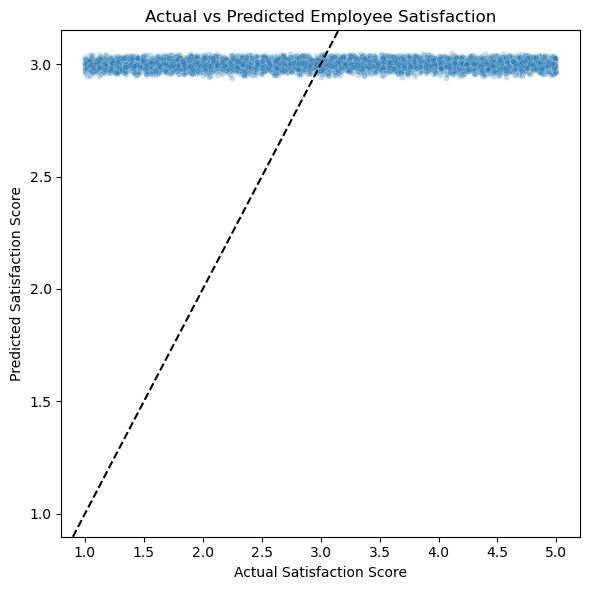

In [25]:
# Actual vs predicted plot for linear regression
plot_df = pd.DataFrame({
    "Actual": analysis_df[satisfaction_col],
    "Predicted": ols_model.fittedvalues
}).sample(n=5000, random_state=189)

plt.figure(figsize=(6, 6))
sns.scatterplot(data=plot_df, x="Actual", y="Predicted", alpha=0.25, s=18)

plt.axline((1, 1), slope=1, linestyle="--", color="black")
plt.title("Actual vs Predicted Employee Satisfaction")
plt.xlabel("Actual Satisfaction Score")
plt.ylabel("Predicted Satisfaction Score")
plt.tight_layout()
plt.show()

**Actual vs Predicted Interpretation**:The actual vs predicted plot shows that the model predictions are concentrated close to 3, while the actual satisfaction scores vary across the full 1–5 scale. This supports the very low \(R^2\) value from the regression model. The model is mostly predicting near the overall average satisfaction score rather than accurately capturing individual differences in employee satisfaction.

# Department-Level Interpretation

The department-level analysis suggests that employee satisfaction is not completely identical across departments, but the differences are very small in practical terms. Operations and IT had the highest average satisfaction scores, while Customer Support had the lowest average satisfaction score. However, all department means were very close to the overall average satisfaction score of approximately 3 on the 1–5 scale.

The one-way ANOVA detected a statistically significant difference in satisfaction across departments (F(8, 99991) = 2.71, p = 0.0055). However, the effect size was extremely small (η² ≈ 0.00022), indicating that department membership explains only about 0.02% of the variation in employee satisfaction. This suggests that while department differences can be detected due to the very large sample size, they are unlikely to be meaningful in practice.

The Tukey HSD post-hoc analysis found that Customer Support employees reported slightly lower satisfaction than employees in Operations and IT. No other department pairs showed significant differences after correcting for multiple comparisons. Even for the significant comparisons, the mean differences were only about 0.05–0.06 points on the satisfaction scale, which is a very small effect.

Overall, the department-level results provide only weak support for our original hypothesis that satisfaction differs across departments. Department may contribute to employee satisfaction to a small degree, but it does not appear to be a major driver of satisfaction in this dataset.

# Limitations

Several limitations should be considered when interpreting the results of this analysis.

1. The dataset is artificially generated rather than collected from real employees. As a result, the relationships observed in the data may not accurately reflect real workplace behavior or employee attitudes.

2. Employee satisfaction is measured on a bounded scale from 1 to 5. Because of this restricted range, standard linear regression assumptions such as normally distributed residuals may not be perfectly satisfied.

3. Important factors that likely influence employee satisfaction are not included in the dataset. Variables such as management quality, workplace culture, leadership effectiveness, work-life balance, interpersonal relationships, and job autonomy may have a much stronger impact on satisfaction than the variables available in this analysis.

4. The very large sample size (100,000 employees) increases statistical power and can make extremely small differences appear statistically significant. Therefore, statistical significance should be interpreted together with effect sizes and practical significance.

5. This study is observational and cannot establish causal relationships. Even when variables are associated with satisfaction, we cannot conclude that they directly cause changes in employee satisfaction.

# Conclusion

The goal of this project was to investigate factors associated with employee satisfaction and determine whether satisfaction varies across departments. While the analyses identified some statistically significant differences between departments, the observed effects were extremely small. Customer Support employees reported slightly lower satisfaction than employees in Operations and IT, but overall satisfaction levels were remarkably similar across all departments.

The multiple linear regression model further demonstrated that workplace characteristics such as performance score, promotions, salary, tenure, work hours, overtime hours, and remote work frequency explained almost none of the variation in employee satisfaction. The model's R² value was close to zero, indicating that the available variables provide very limited predictive power.

Overall, the findings suggest that employee satisfaction is not strongly explained by the variables included in this dataset. Although some department-level differences exist, they are not substantial enough to support the idea that department membership is a major determinant of employee satisfaction.

# Future Work

Future research should incorporate variables that are more directly related to employee experiences and workplace culture. Factors such as leadership quality, manager support, employee recognition, work-life balance, career development opportunities, and team dynamics may provide stronger explanations for employee satisfaction than the variables available in this dataset.

Using real-world employee survey data would also improve the validity and practical relevance of the analysis. In addition, future studies could investigate department-specific relationships, such as whether the effect of performance, salary, or promotions on satisfaction differs across departments.

Finally, alternative modeling approaches, including interaction models, hierarchical models, or machine learning methods, may help uncover patterns that are not captured by traditional linear regression techniques.